## 데이터 파일

* 카드 소지자의 카드 가맹점 소비 관련 덱스트 데이터
  - 데이터 파일명 : bc_card_output.txt
  - 2019년 6월 전체 소비 데이터 일부
  - 용량 : 13,179KB, 레코드 : 100,002개
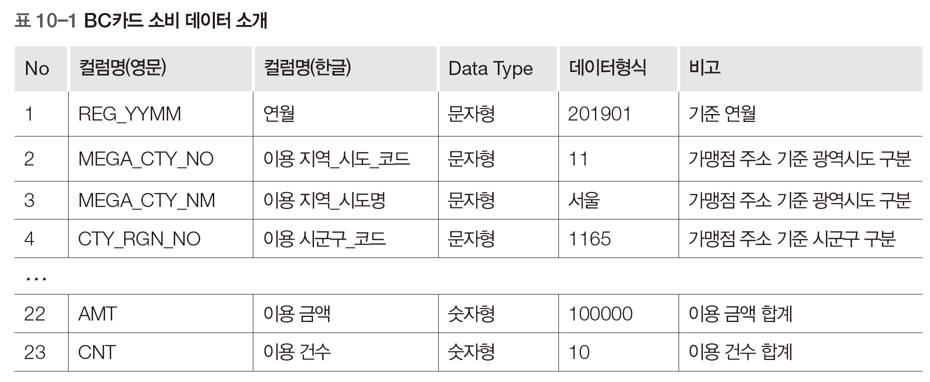

# 1. DataFrame에 데이터 Loading
  1. 데이터 읽어오기
  1. 데이터 전처리 (DataFrame으로 변환가능한 데이터로 정제하기)
  1. DataFrame으로 변환하기

## 1-1. 데이터 읽어오기
* 파일에서 데이터 읽기
* 데이터 크기 확인

In [59]:
card_data = './data/bc_card_utf.txt'
with open(card_data, mode='r') as f:
    data = f.read()
len(data)

10235713

* DataFrame으로 읽어올 수 있는지 확인 -> 데이터 100개만 출력

In [60]:
data[:100]

'REG_YYMM\tMEGA_CTY_NO\tMEGA_CTY_NM\tCTY_RGN_NO\tCTY_RGN_NM\tADMI_CTY_NO\tADMI_CTY_NM\tMAIN_BUZ_CODE\tMAIN_BU'

* String 데이터를 '\t'기준으로 split하여 List로 변환
* 아이템 갯수와 50개의 데이터 확인하기

In [61]:
split_data = data.split('\t')
len(split_data), split_data[:50]

(2200045,
 ['REG_YYMM',
  'MEGA_CTY_NO',
  'MEGA_CTY_NM',
  'CTY_RGN_NO',
  'CTY_RGN_NM',
  'ADMI_CTY_NO',
  'ADMI_CTY_NM',
  'MAIN_BUZ_CODE',
  'MAIN_BUZ_DESC',
  'TP_GRP_NO',
  'TP_GRP_NM',
  'TP_BUZ_NO',
  'TP_BUZ_NM',
  'CSTMR_GUBUN',
  'CSTMR_MEGA_CTY_NO',
  'CSTMR_MEGA_CTY_NM',
  'CSTMR_CTY_RGN_NO',
  'CSTMR_CTY_RGN_NM',
  'SEX_CTGO_CD',
  'AGE_VAL',
  'FLC',
  'AMT',
  'CNT201906',
  '11',
  '서울특별시',
  '1162',
  '관악구',
  '11620585',
  '낙성대동',
  '80',
  '음식',
  '80',
  '일반음식',
  '8006',
  '서양음식',
  '내국인',
  '11',
  '서울특별시',
  '1162',
  '관악구',
  '2',
  '30대',
  '2',
  '26284804',
  '1892201906',
  '11',
  '서울특별시',
  '1159',
  '동작구',
  '11590560'])

* 원본 데이터의 22번째, 23번째 데이터 확인하기

In [62]:
split_data[21], split_data[22]

('AMT', 'CNT201906')

* 컬럼 수가 23개인지 확인해보기 -> split_data를 23으로 나누었을 때 나머지가 0이어야 함

In [63]:
num_cols = 23
len(split_data) % num_cols

3

## 1-2. DataFrame으로 변환가능한 데이터로 정제하기

#### || 22번째 컬럼에 해당하는 데이터 분리하기
  1. 22번째 컬럼의 데이터를 분리하여 \t 추가하기
  1. List 데이터를 \t롤 연결하기
  1. 다시 \로 split 하기

#### 기존 데이터 backup해 놓기

In [64]:
backup_data = split_data.copy()

####  || 리스트를 분리

* 22번쨰 컬럼에 해당하는 데이터를 분리하고 \t 추가 (몇 개 데이터로 결과 확인)

In [65]:
for idx in range(22, len(split_data), 22):
    if split_data[idx].find('201906') > 0:
        split_data[idx] = f'{split_data[idx][:-6]}\t201906'

* List 데이터를 \t로 join하여 하나의 string으로 만들기 (25개 데이터로 결과 확인)

In [66]:
join_split_data = '\t'.join(split_data)

* string을 다시 \t를 기준으로 split하기

In [67]:
new_split_data = join_split_data.split('\t')
new_split_data[:25]

['REG_YYMM',
 'MEGA_CTY_NO',
 'MEGA_CTY_NM',
 'CTY_RGN_NO',
 'CTY_RGN_NM',
 'ADMI_CTY_NO',
 'ADMI_CTY_NM',
 'MAIN_BUZ_CODE',
 'MAIN_BUZ_DESC',
 'TP_GRP_NO',
 'TP_GRP_NM',
 'TP_BUZ_NO',
 'TP_BUZ_NM',
 'CSTMR_GUBUN',
 'CSTMR_MEGA_CTY_NO',
 'CSTMR_MEGA_CTY_NM',
 'CSTMR_CTY_RGN_NO',
 'CSTMR_CTY_RGN_NM',
 'SEX_CTGO_CD',
 'AGE_VAL',
 'FLC',
 'AMT',
 'CNT',
 '201906',
 '11']

## 1-3. 데이터프레임 형식으로 저장하기
  1. 2차원 List로 변경
  1. DataFrame으로 저장 : 첫번째 열은 column 제목으로, 두번째 열부터는 데이터로 지정
  1. DataFrame을 CSV로 저장

In [68]:
data_list = [new_split_data[idx:idx+num_cols] for idx in range(0, len(new_split_data), num_cols)]
data_list[0]

['REG_YYMM',
 'MEGA_CTY_NO',
 'MEGA_CTY_NM',
 'CTY_RGN_NO',
 'CTY_RGN_NM',
 'ADMI_CTY_NO',
 'ADMI_CTY_NM',
 'MAIN_BUZ_CODE',
 'MAIN_BUZ_DESC',
 'TP_GRP_NO',
 'TP_GRP_NM',
 'TP_BUZ_NO',
 'TP_BUZ_NM',
 'CSTMR_GUBUN',
 'CSTMR_MEGA_CTY_NO',
 'CSTMR_MEGA_CTY_NM',
 'CSTMR_CTY_RGN_NO',
 'CSTMR_CTY_RGN_NM',
 'SEX_CTGO_CD',
 'AGE_VAL',
 'FLC',
 'AMT',
 'CNT']

In [69]:
data_list[10]

['201906',
 '11',
 '서울특별시',
 '1114',
 '중구',
 '11140550',
 '명동',
 '10',
 'T&E',
 '20',
 '레져용품',
 '2002',
 '스포츠레져용품',
 '내국인',
 '28',
 '인천광역시',
 '2817',
 '미추홀구',
 '1',
 '20대',
 '1',
 '10002400',
 '117']

In [70]:
# 2차원 리스트를 데이터프레임으로 변환(생성)
import pandas as pd
final_df = pd.DataFrame(data_list[1:], columns=data_list[0])
final_df.head()

,REG_YYMM,MEGA_CTY_NO,MEGA_CTY_NM,CTY_RGN_NO,CTY_RGN_NM,ADMI_CTY_NO,ADMI_CTY_NM,MAIN_BUZ_CODE,MAIN_BUZ_DESC,TP_GRP_NO,...,CSTMR_GUBUN,CSTMR_MEGA_CTY_NO,CSTMR_MEGA_CTY_NM,CSTMR_CTY_RGN_NO,CSTMR_CTY_RGN_NM,SEX_CTGO_CD,AGE_VAL,FLC,AMT,CNT
0,201906,11,서울특별시,1162,관악구,11620585,낙성대동,80,음식,80,...,내국인,11,서울특별시,1162,관악구,2,30대,2,26284804,1892
1,201906,11,서울특별시,1159,동작구,11590560,상도4동,30,생활,40,...,내국인,11,서울특별시,1165,서초구,2,20대,1,109290,18
2,201906,11,서울특별시,1162,관악구,11620595,청룡동,30,생활,83,...,내국인,11,서울특별시,1162,관악구,1,20대,1,268850,52
3,201906,11,서울특별시,1144,마포구,11440660,서교동,80,음식,80,...,내국인,11,서울특별시,1138,은평구,1,20대,1,44174450,1790
4,201906,11,서울특별시,1120,성동구,11200550,사근동,80,음식,80,...,내국인,11,서울특별시,1120,성동구,1,20대,1,60338146,3536


In [71]:
final_df.tail()

,REG_YYMM,MEGA_CTY_NO,MEGA_CTY_NM,CTY_RGN_NO,CTY_RGN_NM,ADMI_CTY_NO,ADMI_CTY_NM,MAIN_BUZ_CODE,MAIN_BUZ_DESC,TP_GRP_NO,...,CSTMR_GUBUN,CSTMR_MEGA_CTY_NO,CSTMR_MEGA_CTY_NM,CSTMR_CTY_RGN_NO,CSTMR_CTY_RGN_NM,SEX_CTGO_CD,AGE_VAL,FLC,AMT,CNT
99996,201906,11,서울특별시,1165,서초구,11650520,서초2동,30,생활,40,...,내국인,43,충청북도,4311,청주시,1,50대,4,50600,10
99997,201906,11,서울특별시,1117,용산구,11170520,용산2가동,30,생활,40,...,내국인,11,서울특별시,1162,관악구,1,40대,2,38640,7
99998,201906,11,서울특별시,1156,영등포구,11560535,영등포동,30,생활,40,...,내국인,28,인천광역시,2817,미추홀구,2,30대,2,340590,15
99999,201906,11,서울특별시,1141,서대문구,11410585,신촌동,40,쇼핑,42,...,내국인,44,충청남도,4413,천안시,1,20대,2,117100,3
100000,201906,11,서울특별시,1135,노원구,11350710,상계9동,20,문화,51,...,내국인,41,경기도,4115,의정부시,1,40대,3,5227500,7


In [72]:
final_df.to_csv(card_data.replace('_utf.txt', '201906.csv'))

In [76]:
card_data = pd.read_csv('./data/bc_card201906.csv')
card_data.head()


,Unnamed: 0,REG_YYMM,MEGA_CTY_NO,MEGA_CTY_NM,CTY_RGN_NO,CTY_RGN_NM,ADMI_CTY_NO,ADMI_CTY_NM,MAIN_BUZ_CODE,MAIN_BUZ_DESC,...,CSTMR_GUBUN,CSTMR_MEGA_CTY_NO,CSTMR_MEGA_CTY_NM,CSTMR_CTY_RGN_NO,CSTMR_CTY_RGN_NM,SEX_CTGO_CD,AGE_VAL,FLC,AMT,CNT
0,0,201906,11,서울특별시,1162,관악구,11620585,낙성대동,80,음식,...,내국인,11,서울특별시,1162,관악구,2,30대,2,26284804,1892
1,1,201906,11,서울특별시,1159,동작구,11590560,상도4동,30,생활,...,내국인,11,서울특별시,1165,서초구,2,20대,1,109290,18
2,2,201906,11,서울특별시,1162,관악구,11620595,청룡동,30,생활,...,내국인,11,서울특별시,1162,관악구,1,20대,1,268850,52
3,3,201906,11,서울특별시,1144,마포구,11440660,서교동,80,음식,...,내국인,11,서울특별시,1138,은평구,1,20대,1,44174450,1790
4,4,201906,11,서울특별시,1120,성동구,11200550,사근동,80,음식,...,내국인,11,서울특별시,1120,성동구,1,20대,1,60338146,3536


### new List append 

In [ ]:
new_list = []

for idx in range(len(split_data)):
    if idx != 0 and idx % 22 == 0 and split_data[idx].endswith('201906'):
        new_list.append(split_data[idx][:-6])
        new_list.append(split_data[idx][-6:])
    else:
        new_list.append(split_data[idx])